# SBC VS TARP (Multivariate Normal)

In [1]:
import numpy as np
import random
from scipy import stats
import matplotlib.pyplot as plt
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
from sbi.diagnostics import run_sbc, check_sbc, run_tarp, check_tarp
from sbi.analysis import sbc_rank_plot
from sbi.analysis import plot_tarp

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

## High correlated parameters

Y follows a multivariate normal distributon, and X is the observed data which adds a shift and small random noise to Y.

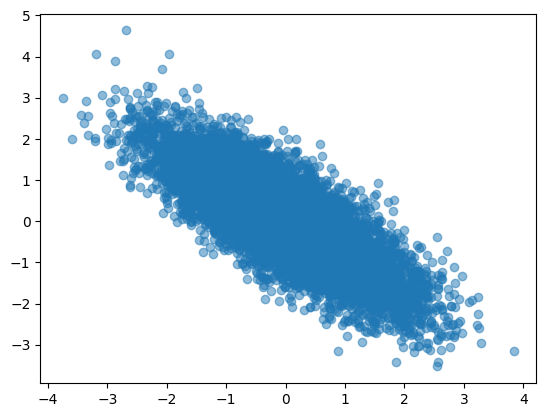

In [3]:
np.random.seed(100)
y = np.random.multivariate_normal(mean=[0, 0], cov=[[1, -0.8], [-0.8, 1]], size=11000)
plt.scatter(y[:, 0], y[:, 1], alpha=0.5)
plt.show()

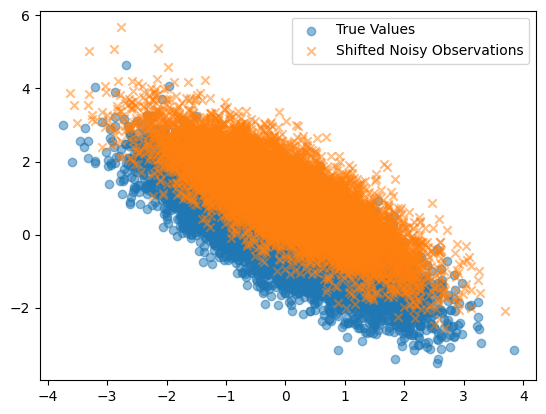

In [4]:
x = y.copy()
x[:, 0] = x[:, 0] + np.random.normal(0, 0.1, size=x.shape[0])
x[:, 1] = x[:, 1] + np.random.normal(1, 0.1, size=x.shape[0])
plt.scatter(y[:, 0], y[:, 1], alpha=0.5, label='True Values')
plt.scatter(x[:, 0], x[:, 1], alpha=0.5, marker='x', label='Shifted Noisy Observations')
plt.legend()
plt.show()

In [5]:
y_train = y[:10000]
x_train = x[:10000]
y_test = y[10000:]
x_test = x[10000:]
print(y_train.shape, x_train.shape, y_test.shape, x_test.shape)

(10000, 2) (10000, 2) (1000, 2) (1000, 2)


In [6]:
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=torch_device)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=torch_device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device=torch_device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=torch_device)
print(y_train_tensor.shape, x_train_tensor.shape, y_test_tensor.shape, x_test_tensor.shape)

torch.Size([10000, 2]) torch.Size([10000, 2]) torch.Size([1000, 2]) torch.Size([1000, 2])


In [7]:
prior_1 = Uniform(low=torch.tensor([-5.0]), high=torch.tensor([5.0]))
prior_2 = Uniform(low=torch.tensor([-5.0]), high=torch.tensor([5.0]))

prior = MultipleIndependent(
    dists=[prior_1, prior_2],
    validate_args=False,
    device=torch_device
)

Try seed = 1, 2, 3

In [8]:
seed = 1
num_posterior_samples=1000
set_seed(seed)

inference1 = NPE_C(prior=prior, density_estimator='nsf', device=torch_device)

In [9]:
density_estimator1 = inference1.append_simulations(y_train_tensor, x_train_tensor).train(
    max_num_epochs=500,
    learning_rate=0.0005
)
posterior1 = inference1.build_posterior(density_estimator1)

 Neural network successfully converged after 59 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-08-27T13_53_49.398778' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


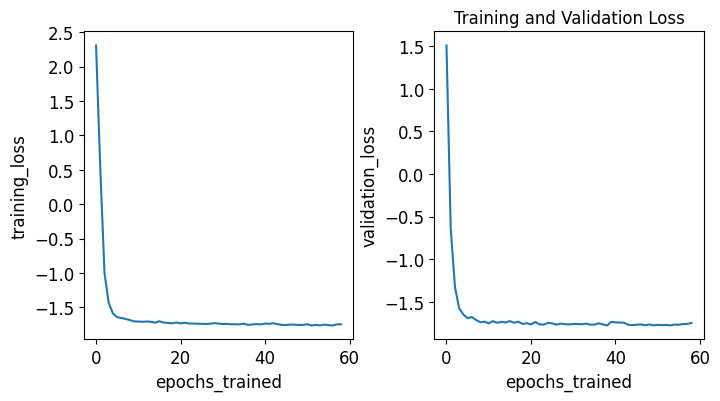

In [10]:
fig, axes = plot_summary(
    inference1, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

In [11]:
y_pred = np.full((y_test.shape[0], num_posterior_samples, 2), np.nan)
for i in range(y_test.shape[0]):
    y_pred[i] = posterior1.sample((num_posterior_samples,),
                                  x=x_test_tensor[i].unsqueeze(0),
                                  show_progress_bars=False
                                  ).cpu().numpy()
y_pred.shape

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


(1000, 1000, 2)

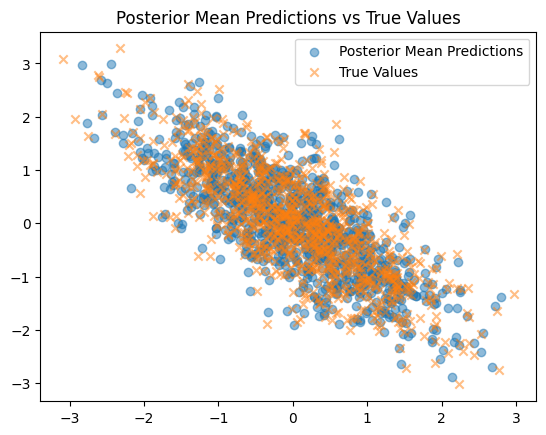

In [12]:
y_pred_mean = np.mean(y_pred, axis=1)
plt.scatter(y_pred_mean[:, 0], y_pred_mean[:, 1], alpha=0.5, label='Posterior Mean Predictions')
plt.scatter(y_test[:, 0], y_test[:, 1], alpha=0.5, marker='x', label='True Values')
plt.title("Posterior Mean Predictions vs True Values")
plt.legend()
plt.show()

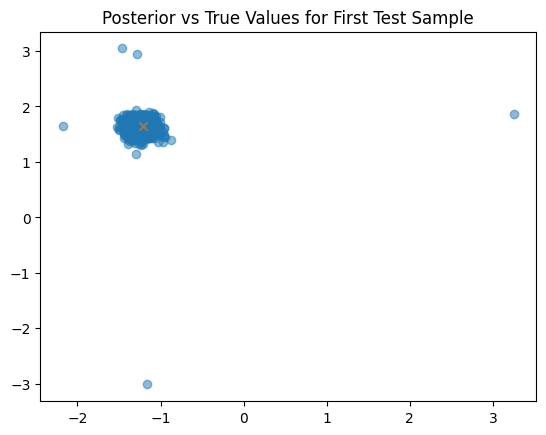

In [13]:
plt.scatter(y_pred[0, :, 0], y_pred[0, :, 1], alpha=0.5)
plt.scatter(y_test[0, 0], y_test[0, 1], alpha=0.5, marker='x')
plt.title("Posterior vs True Values for First Test Sample")
plt.show()

In [14]:
def plot_sbc_ecdf_diff(ranks, num_posterior_samples, param_names=None):
    """
    Plots the ECDF Difference plot for SBC ranks.
    """
    ranks_np = np.array(ranks)
    num_sims, num_params = ranks_np.shape
    
    plt.figure(figsize=(10, 8))

    x_eval = np.linspace(0, 1, 1000)

    std_err = np.sqrt(x_eval * (1 - x_eval) / num_sims)
    envelope_upper = 1.96 * std_err
    envelope_lower = -1.96 * std_err

    plt.fill_between(x_eval, envelope_lower, envelope_upper, color='grey', alpha=0.3, label='95% Confidence')
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

    for i in range(num_params):
        param_ranks = ranks_np[:, i] / num_posterior_samples

        empirical_cdf = np.searchsorted(np.sort(param_ranks), x_eval, side='right') / num_sims

        diff = empirical_cdf - x_eval
        
        label = param_names[i] if param_names else f'Param {i}'
        plt.plot(x_eval, diff, label=label, linewidth=2)

    plt.title("SBC ECDF Difference Plot")
    plt.xlabel("Fractional Rank")
    plt.ylabel("Difference from Uniform CDF")
    plt.legend(frameon=False)
    plt.show()

In [15]:
sbc_results = []
np.random.seed(100)
torch.manual_seed(100)
num_posterior_samples = 1000
parameter_labels = ["Dim 1", "Dim 2"]
ranks, dap_samples = run_sbc(
    y_test_tensor,
    x_test_tensor,
    posterior1,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
    reject_outside_prior=False
)

stats_sbc = check_sbc(
    ranks, 
    y_test_tensor, 
    dap_samples, 
    num_posterior_samples=num_posterior_samples
)

sbc_results.append({
    "ranks": ranks, 
    "stats": stats_sbc
})

Calculating ranks for 1000 SBC samples: 100%|██████████| 1000/1000 [00:00<00:00, 19106.88it/s]


In [16]:
print(stats_sbc)

{'ks_pvals': tensor([0.0281, 0.6034]), 'c2st_ranks': tensor([0.5930, 0.5845], dtype=torch.float64), 'c2st_dap': tensor([0.5000, 0.4760], dtype=torch.float64)}


In [17]:
print("Kolmogorov-Smirnov Test Results (SBC):")
print("-" * 45)

num_dimensions = ranks.shape[1] 

for dim in range(num_dimensions):
    normalized_ranks = ranks[:, dim] / num_posterior_samples
    ks_stat, p_value = stats.kstest(normalized_ranks, 'uniform')
    
    print(f"Parameter:        {parameter_labels[dim]}")
    print(f"KS Statistic (D): {ks_stat:.4f}")
    print(f"p-value:          {p_value:.4e}")

    if p_value < 0.05:
        print("Status: MISCALIBRATED (reject null)")
    else:
        print("Status: CALIBRATED (fail to reject null)")
    print("-" * 45)

Kolmogorov-Smirnov Test Results (SBC):
---------------------------------------------
Parameter:        Dim 1
KS Statistic (D): 0.0460
p-value:          2.8139e-02
Status: MISCALIBRATED (reject null)
---------------------------------------------
Parameter:        Dim 2
KS Statistic (D): 0.0240
p-value:          6.0341e-01
Status: CALIBRATED (fail to reject null)
---------------------------------------------


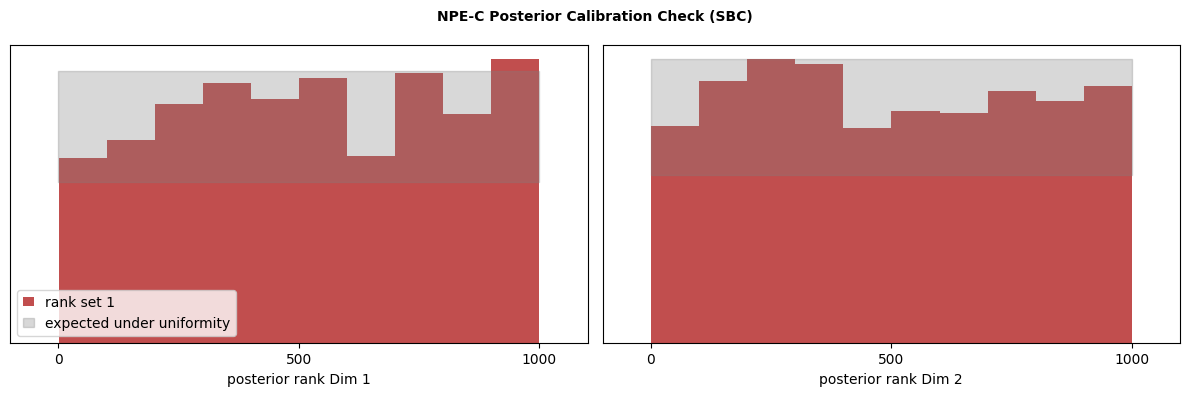

In [18]:
fig, ax = sbc_rank_plot(
    ranks, 
    num_posterior_samples, 
    plot_type="hist", 
    num_bins=10, 
    figsize=(12, 4),
    parameter_labels=parameter_labels
)

fig.suptitle('NPE-C Posterior Calibration Check (SBC)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\u2008181\AppData\Local\Temp\ipykernel_26808\1800669780.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ranks_np = np.array(ranks)


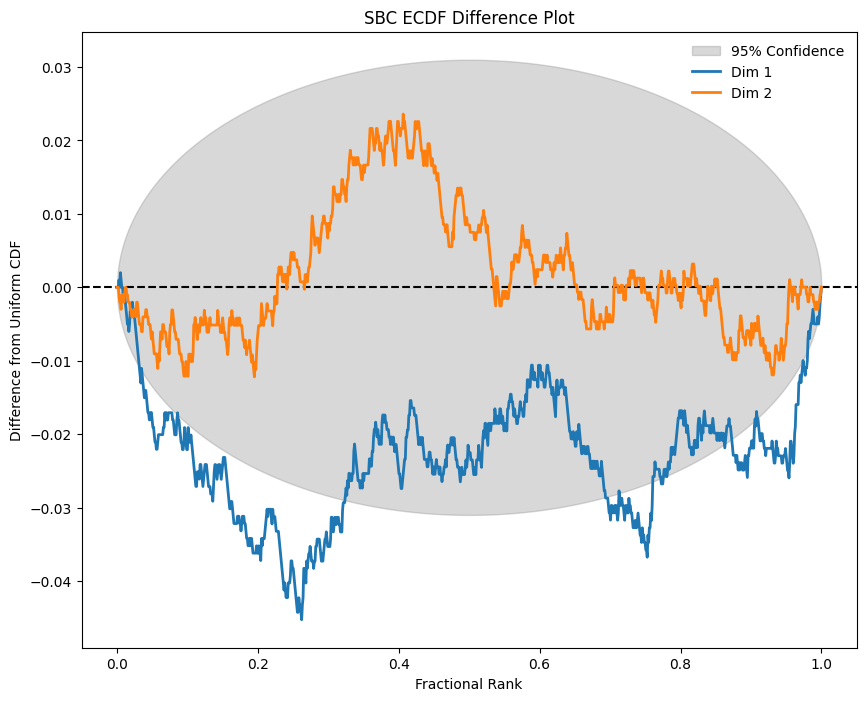

In [19]:
plot_sbc_ecdf_diff(ranks, num_posterior_samples=1000,
                   param_names=parameter_labels)

In [22]:
tarp_results = []
np.random.seed(100)
torch.manual_seed(100)
ecp, alpha = run_tarp(
    y_test_tensor,
    x_test_tensor,
    posterior1,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False
)

Sampling 1000 times (1000,) posterior samples.: 100%|██████████| 1000/1000 [00:18<00:00, 52.98it/s]


In [24]:
stats_tarp = check_tarp(
    ecp,
    alpha
)

tarp_results.append({
    "ecp": ecp,
    "alpha": alpha,
    "stats": stats_tarp
})

In [25]:
print(stats_tarp)

(-0.006643302738666534, np.float64(0.9999989894844649))


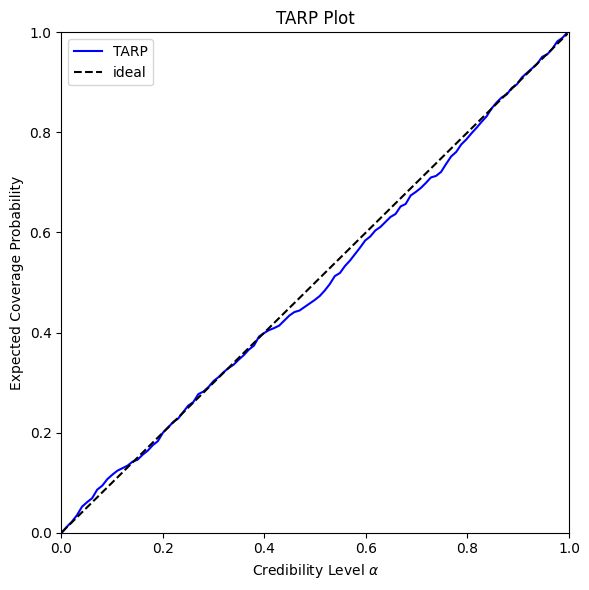

In [26]:
fig, ax = plot_tarp(
    ecp, 
    alpha,
    title="TARP Plot"
)

plt.tight_layout()
plt.show()